In [2]:
# read data
import pandas as pd

train = pd.read_csv("titanic/train.csv")
test = pd.read_csv("titanic/test.csv")

In [3]:
# checkout out first few rows
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# checkout out dataframe info
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
# describe the dataframe
train.describe(include="all")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


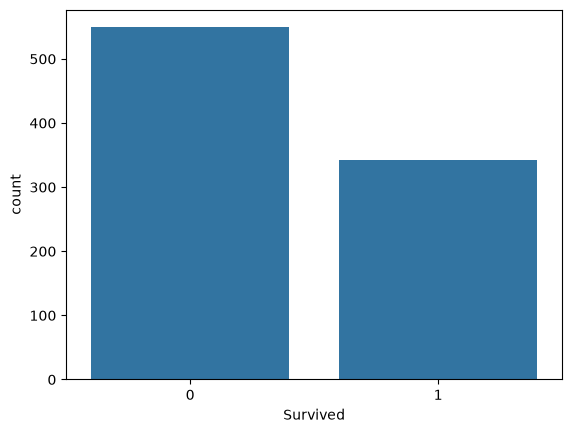

In [6]:
# visualize the dataset, starting with the Survied distribution
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="Survived", data=train)
plt.show()

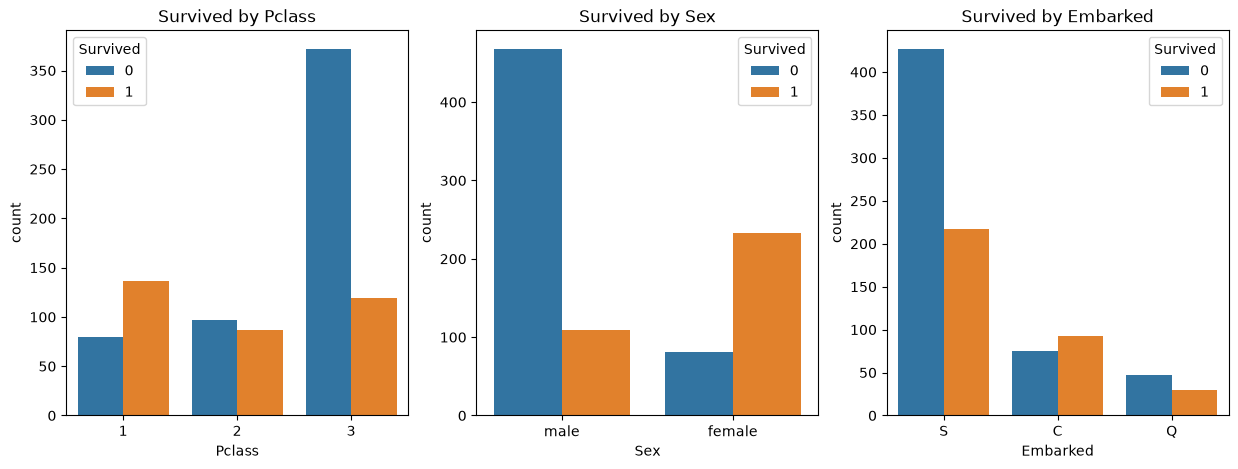

In [ ]:
# Survived w.r.t Pclass / Sex / Embarked ?
# I decided to visualize Pclass, Sex and Embarked
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.countplot(x="Pclass", hue="Survived", data=train, ax=axes[0])
axes[0].set_title("Survived by Pclass")
# With Count I can see how many are in each category
sns.countplot(x="Sex", hue="Survived", data=train, ax=axes[1])
axes[1].set_title("Survived by Sex")

sns.countplot(x="Embarked", hue="Survived", data=train, ax=axes[2])
axes[2].set_title("Survived by Embarked")

plt.show()

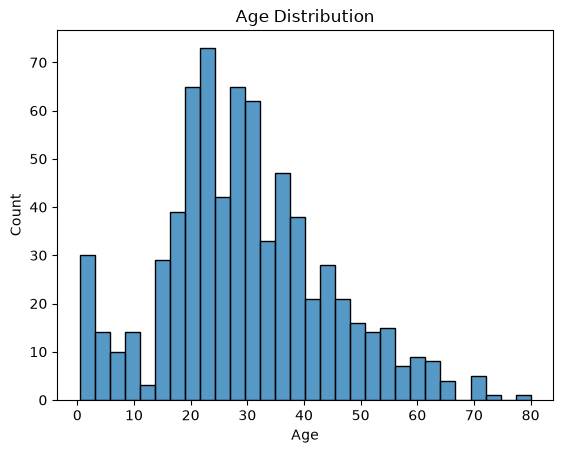

In [8]:
# Age distribution ?
sns.histplot(train["Age"].dropna(), bins=30)
plt.title("Age Distribution")
plt.show()


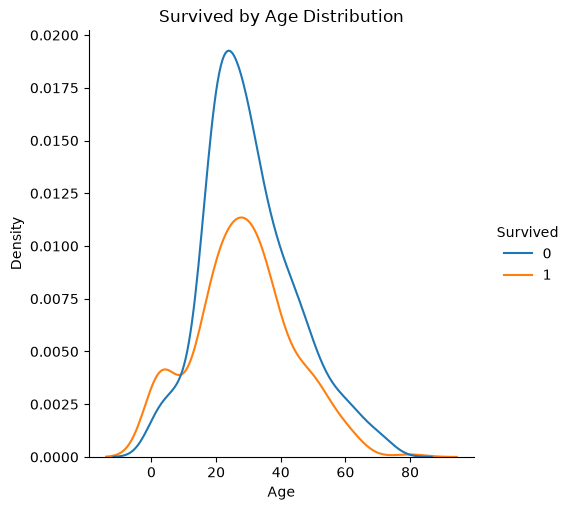

In [9]:
# Survived w.r.t Age distribution ?
sns.displot(train, x="Age", hue="Survived", kind="kde")
plt.title("Survived by Age Distribution")
plt.show()


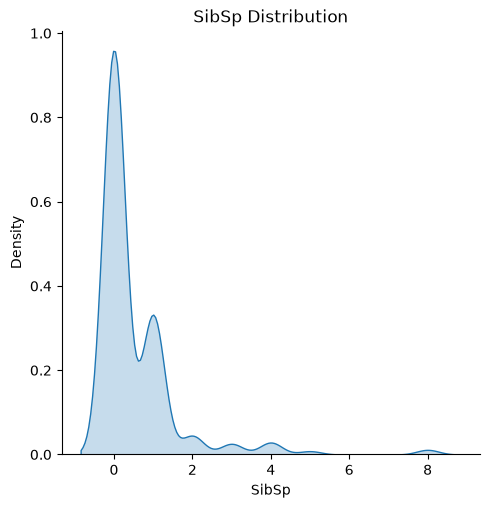

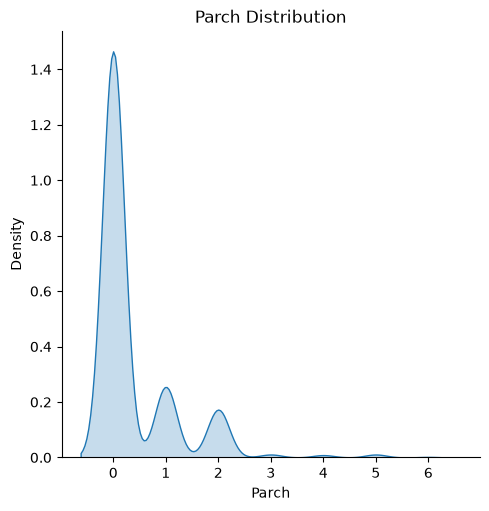

In [ ]:
# SibSp / Parch distribution ?
# I tried to follow the previous visualization based on the assignment's example, 
# using kind="kde" for a smoothing curve that show the distribution

sns.displot(train, x="SibSp", kind="kde", fill=True)
plt.title("SibSp Distribution")
plt.show()

sns.displot(train, x="Parch", kind="kde", fill=True)
plt.title("Parch Distribution")
plt.show()

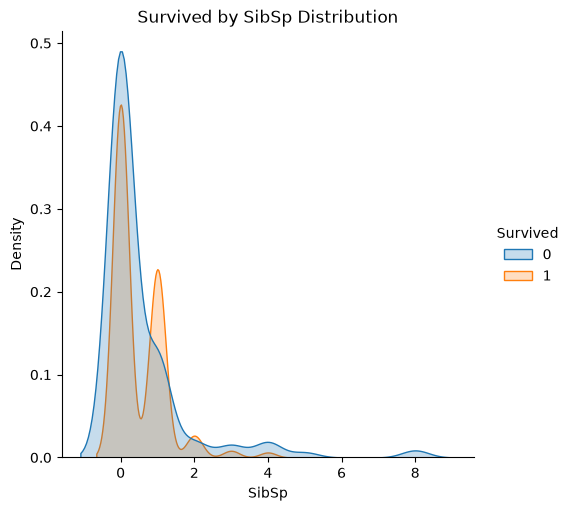

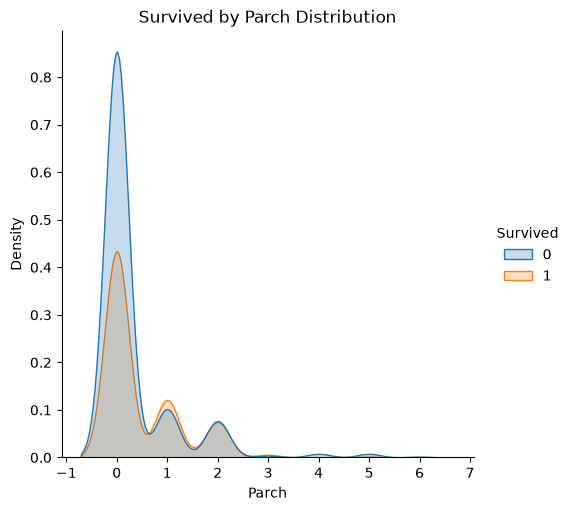

In [ ]:
# Survived w.r.t SibSp / Parch  ?
# Tried to follow the same style with a smoother distribution curve
# Here I also tried to splits the plot by survided/died using hue
sns.displot(train, x="SibSp", hue="Survived", kind="kde", fill=True)
plt.title("Survived by SibSp Distribution")
plt.show()

sns.displot(train, x="Parch", hue="Survived", kind="kde", fill=True)
plt.title("Survived by Parch Distribution")
plt.show()



In [18]:
# Train a Dummy Classifier and evaluate its performance
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score

def evaluate(clf, x, y):
    pred = clf.predict(x)
    result = f1_score(y, pred)
    return f"F1 score: {result:.3f}"

# Try "most_frequent" strategy first
dummy_clf = DummyClassifier(strategy="stratified", random_state=2020)

dummy_selected_columns = ["Pclass"]
dummy_train_x = train[dummy_selected_columns]
dummy_train_y = train["Survived"]

dummy_clf.fit(dummy_train_x, dummy_train_y)

print("Training Set Performance")
print(evaluate(dummy_clf, dummy_train_x, dummy_train_y))

truth = pd.read_csv("truth_titanic.csv")
dummy_test_x = test[dummy_selected_columns]
dummy_test_y = truth["Survived"]

print("Test Set Performance")
print(evaluate(dummy_clf, dummy_test_x, dummy_test_y))

print("Can you do better than a dummy classifier?")

Training Set Performance
F1 score: 0.386
Test Set Performance
F1 score: 0.395
Can you do better than a dummy classifier?


In [ ]:
# Write you solution to this classification problem below
# You must outperform the dummy classifier

from sklearn.ensemble import RandomForestClassifier

# Prepare Training Data
train_copy = train.copy()
test_copy = test.copy()

# Fill missing values
# I used fillna
train_copy["Age"].fillna(train_copy["Age"].median(), inplace=True)
train_copy["Embarked"].fillna(train_copy["Embarked"].mode()[0], inplace=True)

# Encode categorical columns
# I tried to converts categories (male/female) into numbers because ML models
# only understand numbers, to do this I run map
train_copy["Sex"] = train_copy["Sex"].map({"male": 0, "female": 1})
train_copy["Embarked"] = train_copy["Embarked"].map({"S": 0, "C": 1, "Q": 2})

# Prepare Test Data
test_copy["Age"].fillna(train_copy["Age"].median(), inplace=True)
test_copy["Fare"].fillna(test_copy["Fare"].median(), inplace=True)
test_copy["Embarked"].fillna(train_copy["Embarked"].mode()[0], inplace=True)

test_copy["Sex"] = test_copy["Sex"].map({"male": 0, "female": 1})
test_copy["Embarked"] = test_copy["Embarked"].map({"S": 0, "C": 1, "Q": 2})

# Select Features
selected_columns = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
train_x = train_copy[selected_columns]
train_y = train_copy["Survived"]
test_x = test_copy[selected_columns]
test_y = truth["Survived"]

# Train Classifier
# Using RandomForestClassifier I can build 100 decision trees and combines their answers
clf = RandomForestClassifier(n_estimators=100, random_state=2020)
clf.fit(train_x, train_y) # Here I train the model in the data

# Evaluate
print("Training Set Performance")
print(evaluate(clf, train_x, train_y))

print("Test Set Performance")
print(evaluate(clf, test_x, test_y))

# Finally the results are much better than dummy, the F1 score for Training Set Performance is 0.973 (almost 1)
# and the F1 score for Test Set Performance is 0.671


Training Set Performance
F1 score: 0.973
Test Set Performance
F1 score: 0.671


C:\Users\esqui\AppData\Local\Temp\ipykernel_24872\2773965397.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_copy["Age"].fillna(train_copy["Age"].median(), inplace=True)
C:\Users\esqui\AppData\Local\Temp\ipykernel_24872\2773965397.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves